<a href="https://colab.research.google.com/github/dinarojasocho-oss/LAB.-COLAB.02/blob/main/Copia_de_LAB_D5_FGD_PSAYAN_2026_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LABORATORIO DIRIGIDO Nro. 05
## Semana 5: Python, Pandas, normalización y EDA básico

**Curso:** Fundamentos de Gestión de Datos
**Docente:** Pilar Rocío Sayán Mejía
**Modalidad:** Individual
**Nombre del estudiante:**
**Sección:**
**Fecha:**

### Caso de negocio

Abarrotes Esperanza cuenta con una base SQLite de ventas. La base se entrega inicialmente con una sola tabla llamada `ventas_original`, donde se repiten datos de clientes, productos y tiendas.

En este laboratorio primero se explora la tabla desnormalizada, luego se construyen tablas normalizadas con Pandas y SQLite, y finalmente se realiza un EDA básico sobre la información ya organizada.

### Fundamento teórico

| Nro. | Concepto / Principio | Definición aplicada al caso |
| --- | --- | --- |
| 1 | Tabla desnormalizada | Tabla donde se mezclan datos de ventas, clientes, productos y tiendas. |
| 2 | Normalización | Proceso de separar datos repetidos en tablas relacionadas. |
| 3 | Clave primaria | Identificador único de una tabla, como `id_cliente` o `id_producto`. |
| 4 | Clave foránea | Campo que conecta una venta con su cliente, producto o tienda. |
| 5 | DataFrame | Tabla de datos en Pandas. |
| 6 | EDA | Exploración inicial para entender estructura, nulos, duplicados y patrones. |

## Actividad 1: Carga de la base desnormalizada

Vamos a descargar desde GitHub una base SQLite que contiene la tabla `ventas_original`. Esta tabla aún no está normalizada.

In [2]:
# Paso 1: cargar librerías, descargar la base y leer la tabla original
from pathlib import Path
import urllib.request
import sqlite3
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ModuleNotFoundError:
    plt = None
    sns = None
    print("Aviso: matplotlib/seaborn no están disponibles. Se omitirán los gráficos.")

try:
    from IPython.display import display
except Exception:
    display = print

pd.set_option("display.max_columns", None)

url = "https://raw.githubusercontent.com/Rociosayan/PMD1_Fundamentos_Gestion_Datos/main/casos/16_abarrotes_ventas_inventario/abarrotes_ventas_inventario.db"
db_path = Path("abarrotes_ventas_inventario.db")

# Descarga compatible con Google Colab y con cualquier PC (no depende de curl).
# Se descarga siempre para evitar usar una copia antigua guardada en la carpeta.
urllib.request.urlretrieve(url, db_path)

conn = sqlite3.connect(db_path)

ventas_original = pd.read_sql_query("SELECT * FROM ventas_original;", conn)

print("Tabla original cargada:", ventas_original.shape)
display(ventas_original.head(5))

Tabla original cargada: (500, 27)


,id_venta,fecha_operacion,cantidad_unidades,precio_venta_unitario,costo_unitario,descuento_pct,stock_inicial,stock_final,merma_unidades,canal,metodo_pago,monto_venta_soles,margen_venta_soles,observacion,tiendas_nombre,tiendas_distrito,tiendas_zona,tiendas_tipo_local,productos_nombre,productos_categoria,productos_proveedor,productos_costo_unitario,productos_precio_lista,clientes_nombre,clientes_distrito,clientes_segmento,clientes_fecha_registro
0,1,2026-01-22,67,15.06,10.04,8,82,15,0,Mostrador,Tarjeta,375.18,None,Promocion,Abarrotes Esperanza 4,Miraflores,Norte,Tienda de mercado,Cafe instantaneo,Bebidas,Cafe Sierra,9.70,14.87,Marco Quispe,Los Olivos,Vecino frecuente,27/12/2025
1,2,2026-01-04,37,9.42,5.94,8 aprox,223,186,0,WhatsApp,Efectivo,270.35,181.56,Revisar stock,Abarrotes Esperanza 4,Miraflores,Norte,Tienda de mercado,Papel higienico,Limpieza,Suave Hogar,5.76,9.30,Ana Soto,La Molina,Vecino frecuente,2025-12-11
2,3,2026-02-13,8,S/ 5.44,S/ 3.46,0,98,87,3 aprox,Mostrador,Efectivo,80.64,50.32,Revisar stock,Abarrotes Esperanza 6,Comas,Centro,ALMACEN,Lenteja 500g,Menestras,Campo Bueno,3.38,5.14,Marco Mendoza,Ate,Ocasional,2025-08-23
3,4,06/06/2026,44,"12,76",8.24,3,167,123,0,Telefono,Tarjeta,430.38,261.86,Promocion,Abarrotes Esperanza 3,Los Olivos,Norte,Almacen,Aceite vegetal 1L,Aceites,Oleo Andino,8.03,12.76,Miguel Mendoza,Callao,Familia,2025-10-24
4,5,2026-02-19,61,9.28,5.96,0,180,118,1,Mostrador,Yape,460.04,268.68,Promocion,Abarrotes Esperanza 2,La Molina,Norte,Almacen,Papel higienico,Limpieza,Suave Hogar,5.76,9.30,Camila Castillo,San Miguel,Negocio,2025-12-18


**Pregunta 1:** ¿Cuántas filas y columnas tiene `ventas_original`? ¿Por qué se considera una tabla desnormalizada?

Respuesta: Tiene 500 filas y 27 columnas. Es una tabla desnormalizada porque guarda toda la información junta en una sola tabla. Ahí se mezclan datos de ventas, clientes, productos y tiendas. Esto puede causar datos repetidos y errores si luego se necesita corregir el nombre de un cliente, producto o tienda.

## Actividad 2: Exploración inicial de la tabla original

Antes de normalizar, observamos columnas, tipos de datos y valores faltantes.

In [3]:
# Paso 2: revisar estructura de la tabla original
ventas_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_venta                  500 non-null    int64  
 1   fecha_operacion           486 non-null    object 
 2   cantidad_unidades         485 non-null    object 
 3   precio_venta_unitario     491 non-null    object 
 4   costo_unitario            491 non-null    object 
 5   descuento_pct             486 non-null    object 
 6   stock_inicial             489 non-null    object 
 7   stock_final               483 non-null    object 
 8   merma_unidades            491 non-null    object 
 9   canal                     485 non-null    object 
 10  metodo_pago               477 non-null    object 
 11  monto_venta_soles         487 non-null    object 
 12  margen_venta_soles        488 non-null    object 
 13  observacion               459 non-null    object 
 14  tiendas_no

In [4]:
nulos_original = ventas_original.isna().sum().sort_values(ascending=False)
print("\nColumnas con más nulos:")
display(nulos_original.head(10))



Columnas con más nulos:


,0
observacion,41
metodo_pago,23
stock_final,17
clientes_nombre,17
clientes_segmento,16
canal,15
cantidad_unidades,15
descuento_pct,14
fecha_operacion,14
monto_venta_soles,13


**Pregunta 2:** ¿Qué grupos de datos se mezclan en `ventas_original`? Piensa en ventas, clientes, productos y tiendas.

Respuesta: En `ventas_original` se mezclan datos de ventas, clientes, productos y tiendas. Por ejemplo, la tabla tiene información de la venta como fecha, cantidad, precio y monto; información del cliente como nombre, distrito y segmento; información del producto como nombre, categoría y proveedor; y datos de la tienda como nombre, distrito y zona. Esto no es lo ideal porque toda la información está junta en una sola tabla y puede generar datos repetidos, valores nulos y errores al analizar.

## Actividad 3: Identificación de datos repetidos

La normalización se justifica cuando la misma información aparece repetida muchas veces.

In [5]:
# Paso 3: medir repetición de clientes, productos y tiendas
clientes_repetidos = (
    ventas_original
    .groupby(["clientes_nombre", "clientes_distrito", "clientes_segmento"])
    .size()
    .reset_index(name="veces_repetido")
    .sort_values("veces_repetido", ascending=False)
)

productos_repetidos = (
    ventas_original
    .groupby(["productos_nombre", "productos_categoria", "productos_proveedor"])
    .size()
    .reset_index(name="veces_repetido")
    .sort_values("veces_repetido", ascending=False)
)

tiendas_repetidas = (
    ventas_original
    .groupby(["tiendas_nombre", "tiendas_distrito", "tiendas_zona"])
    .size()
    .reset_index(name="veces_repetido")
    .sort_values("veces_repetido", ascending=False)
)

print("Clientes repetidos")
display(clientes_repetidos.head(8))
print("Productos repetidos")
display(productos_repetidos.head(8))
print("Tiendas repetidas")
display(tiendas_repetidas.head(8))


Clientes repetidos


,clientes_nombre,clientes_distrito,clientes_segmento,veces_repetido
56,Marco Huaman,San Miguel,Vecino frecuente,12
3,Ana Flores,San Juan de Lurigancho,Ocasional,10
11,Andre Rojas,Comas,Familia,10
14,Camila Campos,San Miguel,Ocasional,10
0,Maria Reyes,Los Olivos,Ocasional,10
51,Luis Quispe,Ventanilla,Negocio,10
60,Maria Ramos,Los Olivos,Vecino frecuente,9
17,Camila Quispe,Surco,Negocio,8


Productos repetidos


,productos_nombre,productos_categoria,productos_proveedor,veces_repetido
11,galletas soda,Snacks,Dulcesur,46
4,Cafe instantaneo,Bebidas,Cafe Sierra,46
0,Aceite vegetal 1L,Aceites,Oleo Andino,45
1,Arroz extra 5kg,granos,Molino Norte,45
3,Azucar rubia 1kg,Endulzantes,Dulce Peru,44
2,Atun en lata,Conservas,Mar Azul,43
9,Papel higienico,Limpieza,Suave Hogar,43
6,Fideos spaghetti,Pastas,Pastas Sol,43


Tiendas repetidas


,tiendas_nombre,tiendas_distrito,tiendas_zona,veces_repetido
5,Abarrotes Esperanza 6,Comas,Centro,83
3,Abarrotes Esperanza 4,Miraflores,Norte,81
2,Abarrotes Esperanza 3,Los Olivos,Norte,77
0,Abarrotes Esperanza 1,Los Olivos,Sur,72
1,Abarrotes Esperanza 2,La Molina,Norte,66
6,Abarrotes Esperanza 7,La Molina,Sur,61
4,Abarrotes Esperanza 5,La Molina,Este,60


**Pregunta 3:** ¿Qué información conviene separar en tablas independientes? Sustenta usando las repeticiones observadas.

Respuesta: La información que conviene separar es la de clientes, productos y tiendas. Los resultados se observa que algunos datos se repiten varias veces. Por ejemplo, Marco Huamán aparece 12 veces, Galletas soda aparece 46 veces y Abarrotes Esperanza 6 aparece 83 veces.

Por eso, estos datos deberían estar en tablas separadas. Los clientes deben ir en una tabla clientes, los productos en una tabla productos y las tiendas en una tabla tiendas. De esa manera, la tabla ventas solo guarda los códigos o identificadores y no repite los nombres en cada venta.

## Actividad 4: Limpieza mínima antes de normalizar

Antes de crear las tablas, limpiamos espacios, formatos de texto, fechas y columnas numéricas necesarias.

In [6]:
# Paso 4: preparar una copia limpia para normalizar y analizar
ventas_limpia = ventas_original.copy()

columnas_texto = [
    "canal", "metodo_pago", "observacion",
    "tiendas_nombre", "tiendas_distrito", "tiendas_zona", "tiendas_tipo_local",
    "productos_nombre", "productos_categoria", "productos_proveedor",
    "clientes_nombre", "clientes_distrito", "clientes_segmento"
]

for col in columnas_texto:
    ventas_limpia[col] = (
        ventas_limpia[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

columnas_numericas = [
    "cantidad_unidades", "precio_venta_unitario", "costo_unitario", "descuento_pct",
    "stock_inicial", "stock_final", "merma_unidades",
    "monto_venta_soles", "margen_venta_soles",
    "productos_costo_unitario", "productos_precio_lista"
]

for col in columnas_numericas:
    texto = (
        ventas_limpia[col]
        .astype("string")
        .str.replace("S/", "", regex=False)
        .str.replace("aprox", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    ventas_limpia[col] = pd.to_numeric(texto, errors="coerce")

ventas_limpia["fecha_operacion"] = pd.to_datetime(ventas_limpia["fecha_operacion"], errors="coerce")
ventas_limpia["clientes_fecha_registro"] = pd.to_datetime(
    ventas_limpia["clientes_fecha_registro"],
    errors="coerce",
    dayfirst=True
)

display(ventas_limpia.head(5))


,id_venta,fecha_operacion,cantidad_unidades,precio_venta_unitario,costo_unitario,descuento_pct,stock_inicial,stock_final,merma_unidades,canal,metodo_pago,monto_venta_soles,margen_venta_soles,observacion,tiendas_nombre,tiendas_distrito,tiendas_zona,tiendas_tipo_local,productos_nombre,productos_categoria,productos_proveedor,productos_costo_unitario,productos_precio_lista,clientes_nombre,clientes_distrito,clientes_segmento,clientes_fecha_registro
0,1,2026-01-22,67,15.06,10.04,8,82,15,0,Mostrador,Tarjeta,375.18,<NA>,Promocion,Abarrotes Esperanza 4,Miraflores,Norte,Tienda de mercado,Cafe instantaneo,Bebidas,Cafe Sierra,9.7,14.87,Marco Quispe,Los Olivos,Vecino frecuente,2025-12-27
1,2,2026-01-04,37,9.42,5.94,8,223,186,0,WhatsApp,Efectivo,270.35,181.56,Revisar stock,Abarrotes Esperanza 4,Miraflores,Norte,Tienda de mercado,Papel higienico,Limpieza,Suave Hogar,5.76,9.3,Ana Soto,La Molina,Vecino frecuente,NaT
2,3,2026-02-13,8,5.44,3.46,0,98,87,3,Mostrador,Efectivo,80.64,50.32,Revisar stock,Abarrotes Esperanza 6,Comas,Centro,ALMACEN,Lenteja 500g,Menestras,Campo Bueno,3.38,5.14,Marco Mendoza,Ate,Ocasional,NaT
3,4,NaT,44,12.76,8.24,3,167,123,0,Telefono,Tarjeta,430.38,261.86,Promocion,Abarrotes Esperanza 3,Los Olivos,Norte,Almacen,Aceite vegetal 1L,Aceites,Oleo Andino,8.03,12.76,Miguel Mendoza,Callao,Familia,NaT
4,5,2026-02-19,61,9.28,5.96,0,180,118,1,Mostrador,Yape,460.04,268.68,Promocion,Abarrotes Esperanza 2,La Molina,Norte,Almacen,Papel higienico,Limpieza,Suave Hogar,5.76,9.3,Camila Castillo,San Miguel,Negocio,NaT


**Pregunta 4:** ¿Qué columnas tuvieron que convertirse a numéricas o fechas? ¿Por qué no conviene hacer EDA antes de esta limpieza?

Respuesta: Se convirtieron a número columnas como cantidad_unidades, precio_venta_unitario, costo_unitario, descuento_pct, stock_inicial, stock_final, merma_unidades, monto_venta_soles y margen_venta_soles. También se convirtieron a fecha las columnas fecha_operacion y clientes_fecha_registro.

No conviene hacer el EDA antes de limpiar porque algunos valores tenían textos o símbolos, como “S/” o “aprox”. Si no se limpian, Python puede interpretar esos datos como texto y los cálculos pueden salir incorrectos. Por eso primero se limpian los datos y luego recién se analizan.

## Actividad 5: Construcción de tablas normalizadas

A partir de `ventas_limpia`, construiremos tablas separadas: `clientes`, `categorias`, `productos`, `tiendas` y `ventas`.

In [7]:
# Paso 5: crear tablas normalizadas con Pandas
categorias = (
    ventas_limpia[["productos_categoria"]]
    .drop_duplicates()
    .sort_values("productos_categoria")
    .reset_index(drop=True)
    .rename(columns={"productos_categoria": "categoria"})
)
categorias.insert(0, "id_categoria", range(1, len(categorias) + 1))

productos = (
    ventas_limpia[["productos_nombre", "productos_categoria", "productos_proveedor", "productos_costo_unitario", "productos_precio_lista"]]
    .drop_duplicates(subset=["productos_nombre", "productos_categoria", "productos_proveedor"])
    .sort_values("productos_nombre")
    .reset_index(drop=True)
    .rename(columns={
        "productos_nombre": "producto",
        "productos_categoria": "categoria",
        "productos_proveedor": "proveedor",
        "productos_costo_unitario": "costo_unitario",
        "productos_precio_lista": "precio_lista"
    })
)
productos = productos.merge(categorias, on="categoria", how="left")
productos.insert(0, "id_producto", range(1, len(productos) + 1))
productos = productos[["id_producto", "producto", "id_categoria", "proveedor", "costo_unitario", "precio_lista"]]

clientes = (
    ventas_limpia[["clientes_nombre", "clientes_distrito", "clientes_segmento", "clientes_fecha_registro"]]
    .drop_duplicates(subset=["clientes_nombre", "clientes_distrito", "clientes_segmento"])
    .sort_values("clientes_nombre")
    .reset_index(drop=True)
    .rename(columns={
        "clientes_nombre": "cliente",
        "clientes_distrito": "distrito_cliente",
        "clientes_segmento": "segmento_cliente",
        "clientes_fecha_registro": "fecha_registro"
    })
)
clientes.insert(0, "id_cliente", range(1, len(clientes) + 1))

tiendas = (
    ventas_limpia[["tiendas_nombre", "tiendas_distrito", "tiendas_zona", "tiendas_tipo_local"]]
    .drop_duplicates(subset=["tiendas_nombre", "tiendas_distrito", "tiendas_zona"])
    .sort_values("tiendas_nombre")
    .reset_index(drop=True)
    .rename(columns={
        "tiendas_nombre": "tienda",
        "tiendas_distrito": "distrito_tienda",
        "tiendas_zona": "zona",
        "tiendas_tipo_local": "tipo_local"
    })
)
tiendas.insert(0, "id_tienda", range(1, len(tiendas) + 1))

print("categorias:", categorias.shape)
print("productos:", productos.shape)
print("clientes:", clientes.shape)
print("tiendas:", tiendas.shape)

display(productos.head())


categorias: (10, 2)
productos: (12, 6)
clientes: (90, 5)
tiendas: (7, 5)


,id_producto,producto,id_categoria,proveedor,costo_unitario,precio_lista
0,1,Aceite vegetal 1L,1,Oleo Andino,8.03,12.76
1,2,Arroz extra 5kg,10,Molino Norte,18.95,27.3
2,3,Atun en lata,3,Mar Azul,4.39,6.74
3,4,Azucar rubia 1kg,4,Dulce Peru,3.35,4.79
4,5,Cafe instantaneo,2,Cafe Sierra,9.7,14.87


**Pregunta 5:** ¿Qué columna funciona como clave primaria en cada tabla creada? ¿Qué datos repetidos dejó de tener la tabla de ventas?

Respuesta: Las claves primarias son `id_categoria` para categorias, `id_producto` para productos, `id_cliente` para clientes e `id_tienda` para tiendas. Estas columnas sirven para identificar de forma única cada registro.

Con esta normalización, la tabla ventas ya no necesita repetir nombres de clientes, productos, categorías o tiendas. Esa información queda guardada en tablas separadas y ventas solo usará códigos o IDs para conectarse con ellas.

## Actividad 6: Crear la tabla de ventas con claves

La nueva tabla `ventas` conserva datos propios de la operación y reemplaza textos repetidos por códigos.

In [ ]:
# Paso 6: construir la tabla de ventas normalizada
ventas = ventas_limpia.merge(
    clientes[["id_cliente", "cliente", "distrito_cliente", "segmento_cliente"]],
    left_on=["clientes_nombre", "clientes_distrito", "clientes_segmento"],
    right_on=["cliente", "distrito_cliente", "segmento_cliente"],
    how="left"
)

ventas = ventas.merge(
    productos[["id_producto", "producto"]],
    left_on="productos_nombre",
    right_on="producto",
    how="left"
)

ventas = ventas.merge(
    tiendas[["id_tienda", "tienda", "distrito_tienda", "zona"]],
    left_on=["tiendas_nombre", "tiendas_distrito", "tiendas_zona"],
    right_on=["tienda", "distrito_tienda", "zona"],
    how="left"
)

ventas = ventas[[
    "id_venta", "fecha_operacion", "id_cliente", "id_producto", "id_tienda",
    "cantidad_unidades", "precio_venta_unitario", "costo_unitario", "descuento_pct",
    "stock_inicial", "stock_final", "merma_unidades", "canal", "metodo_pago",
    "monto_venta_soles", "margen_venta_soles"
]].copy()

display(ventas.head(8))
print("ventas normalizada:", ventas.shape)


,id_venta,fecha_operacion,id_cliente,id_producto,id_tienda,cantidad_unidades,precio_venta_unitario,costo_unitario,descuento_pct,stock_inicial,stock_final,merma_unidades,canal,metodo_pago,monto_venta_soles,margen_venta_soles
0,1,2026-01-22,61,5,4,67,15.06,10.04,8,82,15,0,Mostrador,Tarjeta,375.18,<NA>
1,2,2026-01-04,6,10,4,37,9.42,5.94,8,223,186,0,WhatsApp,Efectivo,270.35,181.56
2,3,2026-02-13,60,9,6,8,5.44,3.46,0,98,87,3,Mostrador,Efectivo,80.64,50.32
3,4,NaT,65,1,3,44,12.76,8.24,3,167,123,0,Telefono,Tarjeta,430.38,261.86
4,5,2026-02-19,15,10,2,61,9.28,5.96,0,180,118,1,Mostrador,Yape,460.04,268.68
5,6,2026-01-09,5,2,3,21,28.91,19.0,10,176,155,0,Mostrador,Tarjeta,198.6,-9.56
6,7,2026-01-04,71,11,6,55,7.18,4.89,10,127,72,0,WhatsApp,Efectivo,499.65,408.34
7,8,2026-01-13,29,12,3,51,2.76,1.6,3,265,214,0,WhatsApp,Efectivo,324.68,302.75


ventas normalizada: (500, 16)


**Pregunta 6:** ¿Qué columnas de texto desaparecieron de `ventas` y fueron reemplazadas por identificadores?

Respuesta: Desaparecieron los nombres y datos repetidos de clientes, productos y tiendas. Por ejemplo, ya no aparecen `clientes_nombre`, `productos_nombre` ni `tiendas_nombre` dentro de ventas.

Ahora esos datos fueron reemplazados por `id_cliente`, `id_producto` e `id_tienda`. Esto ayuda a que la tabla ventas esté más ordenada y no repita la misma información muchas veces.

## Actividad 7: Guardar el modelo normalizado en SQLite y validar

Guardamos las nuevas tablas en la misma conexión SQLite y reconstruimos un reporte legible para comprobar que la información no se perdió.

In [ ]:
# Paso 7: guardar tablas normalizadas en SQLite
categorias.to_sql("categorias", conn, if_exists="replace", index=False)
productos.to_sql("productos", conn, if_exists="replace", index=False)
clientes.to_sql("clientes", conn, if_exists="replace", index=False)
tiendas.to_sql("tiendas", conn, if_exists="replace", index=False)
ventas.to_sql("ventas", conn, if_exists="replace", index=False)

consulta_tablas = pd.read_sql_query(
    """
    SELECT name AS tabla
    FROM sqlite_schema
    WHERE type = 'table'
      AND name NOT LIKE 'sqlite_%'
    ORDER BY name
    """,
    conn
)
display(consulta_tablas)

reporte_validacion = pd.read_sql_query(
    """
    SELECT
        v.id_venta,
        v.fecha_operacion,
        c.cliente,
        p.producto,
        cat.categoria,
        t.tienda,
        v.cantidad_unidades,
        v.monto_venta_soles
    FROM ventas v
    LEFT JOIN clientes c ON v.id_cliente = c.id_cliente
    LEFT JOIN productos p ON v.id_producto = p.id_producto
    LEFT JOIN categorias cat ON p.id_categoria = cat.id_categoria
    LEFT JOIN tiendas t ON v.id_tienda = t.id_tienda
    ORDER BY v.id_venta
    LIMIT 10
    """,
    conn
)
display(reporte_validacion)


,tabla
0,categorias
1,clientes
2,productos
3,tiendas
4,ventas
5,ventas_original


,id_venta,fecha_operacion,cliente,producto,categoria,tienda,cantidad_unidades,monto_venta_soles
0,1,2026-01-22 00:00:00,Marco Quispe,Cafe instantaneo,Bebidas,Abarrotes Esperanza 4,67,375.18
1,2,2026-01-04 00:00:00,Ana Soto,Papel higienico,Limpieza,Abarrotes Esperanza 4,37,270.35
2,3,2026-02-13 00:00:00,Marco Mendoza,Lenteja 500g,Menestras,Abarrotes Esperanza 6,8,80.64
3,4,None,Miguel Mendoza,Aceite vegetal 1L,Aceites,Abarrotes Esperanza 3,44,430.38
4,5,2026-02-19 00:00:00,Camila Castillo,Papel higienico,Limpieza,Abarrotes Esperanza 2,61,460.04
5,6,2026-01-09 00:00:00,Ana Paredes,Arroz extra 5kg,granos,Abarrotes Esperanza 3,21,198.60
6,7,2026-01-04 00:00:00,Raul Rojas,Yogurt familiar,Lacteos,Abarrotes Esperanza 6,55,499.65
7,8,2026-01-13 00:00:00,Claudia Salazar,galletas soda,Snacks,Abarrotes Esperanza 3,51,324.68
8,9,2026-03-21 00:00:00,Lucia Salazar,Papel higienico,Limpieza,Abarrotes Esperanza 6,48,334.42
9,10,2026-02-13 00:00:00,Marco Mendoza,Lenteja 500g,Menestras,Abarrotes Esperanza 6,8,80.64


**Pregunta 7:** ¿Por qué se necesita `JOIN` después de normalizar? ¿Qué confirma el reporte de validación?

Respuesta: Después de normalizar se necesita **JOIN** porque la tabla ventas ya no guarda nombres, sino códigos como `id_cliente`, `id_producto` e `id_tienda`. El **JOIN** permite unir esos códigos con las tablas clientes, productos y tiendas para mostrar los nombres reales.

El reporte de validación confirma que la información sigue completa. Aunque ahora está separada en varias tablas, se puede volver a armar un reporte claro con los datos de cada venta.

## Actividad 8: EDA descriptivo sobre la tabla ventas normalizada

Ahora que la base está organizada, analizamos variables numéricas de ventas.

In [ ]:
# Paso 8: estadística descriptiva sobre ventas normalizadas
columnas_eda = [
    "cantidad_unidades",
    "precio_venta_unitario",
    "monto_venta_soles",
    "margen_venta_soles",
    "stock_final"
]

resumen_descriptivo = ventas[columnas_eda].describe()
display(resumen_descriptivo)

nulos = ventas.isna().sum().sort_values(ascending=False)
duplicados = ventas.duplicated().sum()
print("Filas duplicadas en ventas:", duplicados)
display(nulos.head(10))


,cantidad_unidades,precio_venta_unitario,monto_venta_soles,margen_venta_soles,stock_final
count,485.0,491.0,487.0,488.0,483.0
mean,42.65567,9.438208,319.399261,185.158361,123.093168
std,29.420768,6.763202,236.28869,172.214891,66.339764
min,4.0,2.68,13.63,-210.13,8.0
25%,22.0,4.98,168.485,63.185,67.0
50%,42.0,7.18,288.89,162.34,124.0
75%,60.0,12.53,427.755,284.3525,178.5
max,290.0,29.46,2493.24,1369.91,245.0


Filas duplicadas en ventas: 0


,0
fecha_operacion,81
metodo_pago,23
stock_final,17
cantidad_unidades,15
canal,15
descuento_pct,14
monto_venta_soles,13
margen_venta_soles,12
stock_inicial,11
precio_venta_unitario,9


**Pregunta 8:** Según `describe()`, ¿qué variable tiene mayor dispersión? ¿Hay nulos relevantes después de normalizar?

Respuesta: La variable con mayor dispersión es **monto_venta_soles**, porque su desviación estándar es la más alta. Esto quiere decir que no todas las ventas tienen montos parecidos; algunas son bajas y otras más altas.

Sí hay nulos importantes después de normalizar. Por ejemplo, hay valores faltantes en **fecha_operacion**, **metodo_pago**, **stock_final,** **cantidad_unidades**, **canal y monto_venta_soles**. Esto demuestra que normalizar ordena la base de datos, pero no elimina todos los problemas de calidad de datos.



## Actividad 9: Gráficos básicos

Graficamos la distribución del monto de venta y el monto acumulado por categoría.

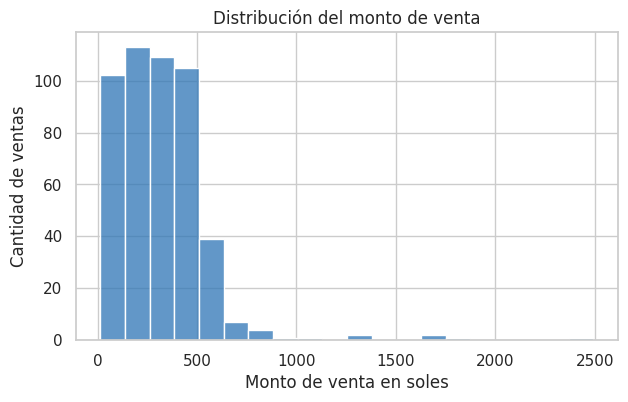

,categoria,monto_venta_soles
0,Limpieza,27006.35
1,Lacteos,21782.2
2,granos,18371.24
3,Aceites,15511.08
4,Bebidas,14065.01
5,Conservas,13362.34
6,Snacks,13305.92
7,Pastas,11826.49
8,Endulzantes,11751.7
9,Menestras,8565.11


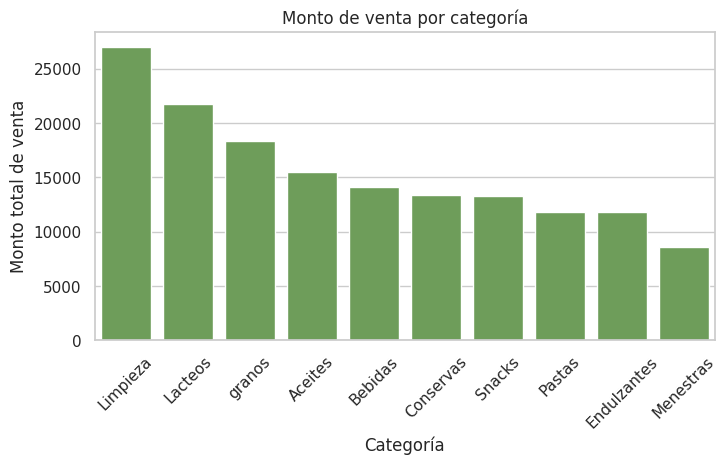

In [ ]:
# Paso 9: histograma y barras por categoría
if plt is not None and sns is not None:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=ventas, x="monto_venta_soles", bins=20, color="#2E75B6")
    plt.title("Distribución del monto de venta")
    plt.xlabel("Monto de venta en soles")
    plt.ylabel("Cantidad de ventas")
    plt.show()
else:
    print("Gráfico omitido porque matplotlib/seaborn no están disponibles.")

ventas_categoria = (
    ventas[["id_producto", "monto_venta_soles"]]
    .merge(productos[["id_producto", "id_categoria"]], on="id_producto", how="left")
    .merge(categorias, on="id_categoria", how="left")
)

ventas_por_categoria = (
    ventas_categoria
    .groupby("categoria")["monto_venta_soles"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(ventas_por_categoria)

if plt is not None and sns is not None:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=ventas_por_categoria, x="categoria", y="monto_venta_soles", color="#6AA84F")
    plt.title("Monto de venta por categoría")
    plt.xlabel("Categoría")
    plt.ylabel("Monto total de venta")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Gráfico omitido porque matplotlib/seaborn no están disponibles.")


**Pregunta 9:** ¿En qué rango se concentran más ventas? ¿Qué categoría tiene mayor monto total de venta?

Respuesta: La mayoría de ventas se concentra entre S/ 0 y S/ 500 aproximadamente. Esto quiere decir que la mayoría de clientes realiza compras de montos pequeños o medianos.

La categoría con mayor monto total de venta es Limpieza, con S/ 27006.35. Por eso, Abarrotes Esperanza debería cuidar el stock de productos de limpieza, porque es una de las categorías que más ingresos genera.

## Actividad 10: Correlación sencilla y cierre

Revisamos una matriz de correlación con variables numéricas clave.

,cantidad_unidades,precio_venta_unitario,monto_venta_soles,margen_venta_soles
cantidad_unidades,1.000000,0.093698,0.877329,0.598663
precio_venta_unitario,0.093698,1.000000,0.145693,-0.491894
monto_venta_soles,0.877329,0.145693,1.000000,0.650695
margen_venta_soles,0.598663,-0.491894,0.650695,1.000000


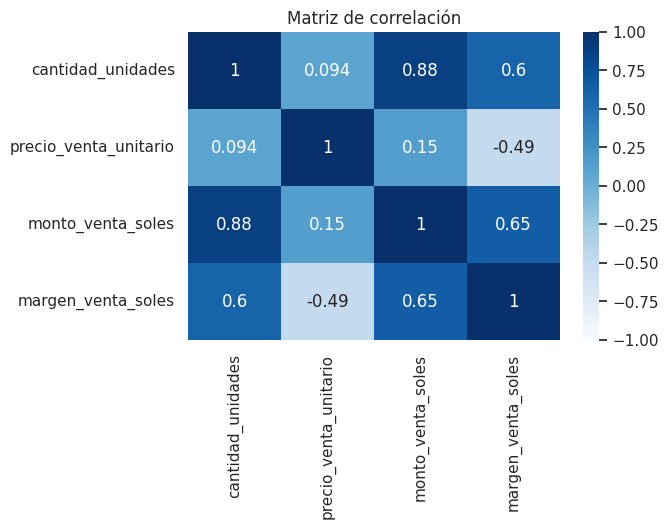

In [ ]:
# Paso 10: matriz de correlación
matriz_correlacion = ventas[[
    "cantidad_unidades",
    "precio_venta_unitario",
    "monto_venta_soles",
    "margen_venta_soles"
]].corr()

display(matriz_correlacion)

if plt is not None and sns is not None:
    plt.figure(figsize=(6, 4))
    sns.heatmap(matriz_correlacion, annot=True, cmap="Blues", vmin=-1, vmax=1)
    plt.title("Matriz de correlación")
    plt.show()
else:
    print("Mapa de calor omitido porque matplotlib/seaborn no están disponibles.")


**Pregunta 10:** Escribe tres conclusiones breves: una sobre normalización, una sobre calidad de datos y una sobre el EDA.

Respuesta: La normalización ayudó a ordenar mejor la base de datos y evitar que se repitan nombres de clientes, productos y tiendas.

En calidad de datos, se observó que todavía hay valores faltantes en algunas columnas, por lo que es necesario revisar esos datos antes de tomar decisiones.

En el EDA se encontró que la cantidad de unidades tiene una relación fuerte con el monto de venta. Esto significa que cuando se venden más unidades, el monto total de la venta suele aumentar.

## MATERIAL COMPLEMENTARIO

- Repositorio PMD1: https://github.com/Rociosayan/PMD1_Fundamentos_Gestion_Datos
- Pandas documentation: https://pandas.pydata.org/docs/
- Seaborn documentation: https://seaborn.pydata.org/